In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import prince
from sklearn.preprocessing import StandardScaler
from func import *

In [13]:
df_transac = pd.read_csv('data/train_transaction.csv', nrows=50000)
df_id = pd.read_csv('data/train_identity.csv', nrows=50000)

print(df_id.head())

   TransactionID  id_01     id_02  id_03  id_04  id_05  id_06  id_07  id_08  \
0        2987004    0.0   70787.0    NaN    NaN    NaN    NaN    NaN    NaN   
1        2987008   -5.0   98945.0    NaN    NaN    0.0   -5.0    NaN    NaN   
2        2987010   -5.0  191631.0    0.0    0.0    0.0    0.0    NaN    NaN   
3        2987011   -5.0  221832.0    NaN    NaN    0.0   -6.0    NaN    NaN   
4        2987016    0.0    7460.0    0.0    0.0    1.0    0.0    NaN    NaN   

   id_09  ...                id_31  id_32      id_33           id_34  id_35  \
0    NaN  ...  samsung browser 6.2   32.0  2220x1080  match_status:2      T   
1    NaN  ...   mobile safari 11.0   32.0   1334x750  match_status:1      T   
2    0.0  ...          chrome 62.0    NaN        NaN             NaN      F   
3    NaN  ...          chrome 62.0    NaN        NaN             NaN      F   
4    0.0  ...          chrome 62.0   24.0   1280x800  match_status:2      T   

  id_36 id_37  id_38  DeviceType                  

In [ ]:
print(f"Dimensions df_id : {df_id.shape}")

In [21]:
print(df_id.select_dtypes(include=['object']).columns)

Index(['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30',
       'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='str')


/var/folders/tm/ltl1_5rx0lq1ps9g4gbyst380000gn/T/ipykernel_94822/4044805073.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_id.select_dtypes(include=['object']).columns)


In [24]:
df_combined = df_id.merge(df_transac[['TransactionID', 'isFraud']], on='TransactionID', how='left')


In [ ]:
const_cols = [col for col in df_combined.columns if df_combined[col].nunique(dropna=True) <= 1]

print(f"Colonnes constantes (ou vides) : {const_cols}")

# Si la liste n'est plus vide, tu peux maintenant les supprimer proprement
if len(const_cols) > 0:
    df_combined.drop(columns=const_cols, inplace=True)
    print(f"{len(const_cols)} removed column.")
else:
    print("No one constant column found.")

Colonnes constantes (ou vides) : []
No one constant column found.


In [ ]:
#Missing values check sorting

na_pourcentage = df_id.isnull().mean() * 100
na_pourcentage.index = df_id.columns
na_pourcentage = na_pourcentage.sort_values(ascending=False)
print(na_pourcentage)

id_24            96.446
id_25            96.192
id_21            96.176
id_07            96.170
id_08            96.170
id_26            96.170
id_23            96.168
id_27            96.168
id_22            96.168
id_18            68.952
id_03            56.354
id_04            56.354
id_09            49.076
id_10            49.076
id_33            31.542
id_30            26.090
id_32            26.086
id_34            25.918
id_14            25.010
id_13            17.894
DeviceInfo       11.388
id_16             7.626
id_06             5.564
id_05             5.564
id_20             3.538
id_19             3.534
id_17             3.510
id_31             2.774
DeviceType        2.674
id_02             2.658
id_28             2.436
id_29             2.436
id_15             2.436
id_11             2.436
id_35             2.436
id_36             2.436
id_37             2.436
id_38             2.436
id_01             0.000
id_12             0.000
TransactionID     0.000
dtype: float64


Some variables have the same percentage of missing values, we will check if it is on the same lines.

In [28]:

threshold = 0.90
high_nan_cols = [col for col in df_combined.columns if df_combined[col].isna().mean() > threshold]

print(f"Colonnes avec > 90% de NaN : {len(high_nan_cols)}")

# 2. Analyse comparative du taux de fraude
results = []

for col in high_nan_cols:
    # On crée un masque binaire : 1 si NaN, 0 si présent
    df_combined['is_nan'] = df_combined[col].isna()
    
    # On calcule le taux de fraude pour les deux groupes
    stats = df_combined.groupby('is_nan')['isFraud'].mean()
    
    results.append({
        'colonne': col,
        'taux_fraude_si_present': stats[False],
        'taux_fraude_si_nan': stats[True],
        'diff': stats[True] - stats[False] # Si positif, le NaN est plus suspect
    })

# 3. Affichage des résultats
df_results = pd.DataFrame(results).sort_values(by='diff', ascending=False)
print(df_results.head(10))

Colonnes avec > 90% de NaN : 9
  colonne  taux_fraude_si_present  taux_fraude_si_nan      diff
3   id_22                0.049342            0.040005 -0.009337
4   id_23                0.049342            0.040005 -0.009337
7   id_26                0.049342            0.040005 -0.009337
8   id_27                0.049342            0.040005 -0.009337
0   id_07                0.049423            0.040003 -0.009421
1   id_08                0.049423            0.040003 -0.009421
2   id_21                0.049669            0.039995 -0.009674
6   id_25                0.050167            0.039980 -0.010187
5   id_24                0.053667            0.039882 -0.013786


The fact that the fraudster leaves a technical trace is a stronger indicator of fraud than the fact that he hides that trace.

In [30]:
cols = ['id_27', 'id_22', 'id_23']

ref_col = cols[0]

print(f"Référence : {ref_col}")
for col in cols[1:]:

    is_sync = df_id[col].isna().equals(df_id[ref_col].isna())
    print(f"{col} est synchronisé avec {ref_col} : {is_sync}")

Référence : id_27
id_22 est synchronisé avec id_27 : True
id_23 est synchronisé avec id_27 : True


<Axes: xlabel='count_missing_tech_block', ylabel='isFraud'>

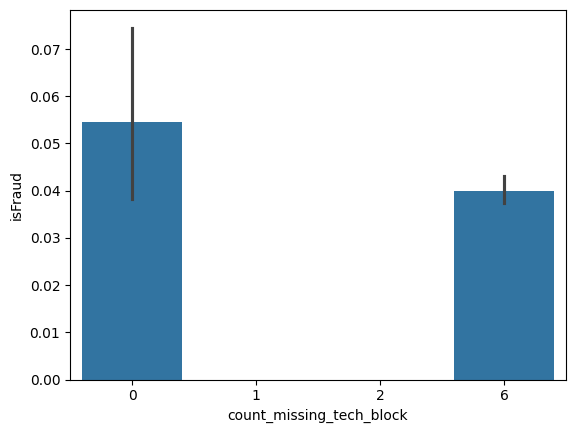

In [16]:
# Ton groupe de colonnes techniques
cols_tech = ['id_21', 'id_22', 'id_24', 'id_25', 'id_26', 'id_27']

# La création de la feature
df_combined['count_missing_tech_block'] = df_combined[cols_tech].isna().sum(axis=1)

# Pour l'EDA (à faire dans ton notebook d'analyse)
sns.barplot(x='count_missing_tech_block', y='isFraud', data=df_combined)

When a transaction provides all its technical information (0 missing), it has a 7% probability of being fraudulent. Conversely, when it hides 6 pieces of technical information, this probability drops to 4%. Hiding this information reduces the risk of fraud by a factor of 3.5.

We could probably say that privacy protection tools or enterprise configurations, which systematically mask technical data, are correlated with trusted user profiles.

In [17]:
df_combined['count_missing_tech_block'].value_counts()

count_missing_tech_block
6    48084
0     1765
1      146
2        5
Name: count, dtype: int64

In [18]:
print(df_id.describe())

       TransactionID         id_01          id_02         id_03         id_04  \
count   5.000000e+04  50000.000000   48671.000000  21823.000000  21823.000000   
mean    3.052775e+06     -8.222920  136714.373611      0.082024     -0.058883   
std     3.126389e+04     13.065504  120775.013660      0.588014      0.699167   
min     2.987004e+06   -100.000000    1120.000000    -11.000000    -28.000000   
25%     3.027580e+06     -5.000000   60521.500000      0.000000      0.000000   
50%     3.056132e+06     -5.000000  103244.000000      0.000000      0.000000   
75%     3.079821e+06     -5.000000  171518.500000      0.000000      0.000000   
max     3.100497e+06      0.000000  999595.000000     10.000000      0.000000   

              id_05         id_06        id_07        id_08         id_09  \
count  47218.000000  47218.000000  1915.000000  1915.000000  25462.000000   
mean       1.956373     -5.928650    14.186945   -39.907050      0.129369   
std        5.333978     15.979236    11

In [19]:
def classify_columns(df):
    cat_cols = []
    num_cols = []
    
    for col in df.columns:
        # Si c'est du texte ou booléen, c'est catégoriel
        if df[col].dtype == 'object' or df[col].dtype == 'bool':
            cat_cols.append(col)
        # Si c'est numérique, on regarde le nombre de valeurs uniques
        else:
            # Seuil arbitraire : moins de 20 valeurs uniques = catégoriel
            if df[col].nunique() < 20:
                cat_cols.append(col)
            else:
                num_cols.append(col)
    return cat_cols, num_cols

cat_cols, num_cols = classify_columns(df_transac)
print(f"Variables catégorielles : {len(cat_cols)}")
print(f"Variables continues : {len(num_cols)}")

Variables catégorielles : 223
Variables continues : 171
